In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pickle
import warnings
warnings.filterwarnings("ignore")

# Load featured dataset
df = pd.read_csv("../data/customers_featured.csv")
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(0)

print("Data loaded successfully!")
print("Shape:", df.shape)

Data loaded successfully!
Shape: (7043, 36)


LTV feature created!

LTV Statistics:
count    7043.000000
mean     2279.581350
std      2264.729447
min         0.000000
25%       394.000000
50%      1393.600000
75%      3786.100000
max      8550.000000
Name: LTV, dtype: float64


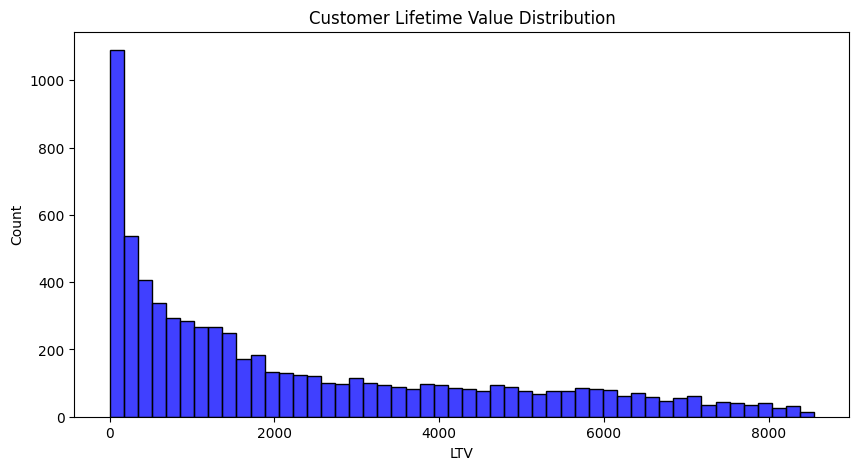

In [2]:
# Create LTV (Lifetime Value) feature
# LTV = Monthly Charges * Tenure
df["LTV"] = df["MonthlyCharges"] * df["tenure"]

print("LTV feature created!")
print("\nLTV Statistics:")
print(df["LTV"].describe())

# Plot LTV distribution
plt.figure(figsize=(10,5))
sns.histplot(df["LTV"], bins=50, color="blue")
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("LTV")
plt.ylabel("Count")
plt.show()

In [3]:
# Prepare LTV features and target
X_ltv = df[["tenure", "MonthlyCharges", "TotalCharges", 
            "TotalServices", "ChargesPerMonth",
            "IsNewCustomer", "IsLongTermCustomer", "IsHighSpender"]]
y_ltv = df["LTV"]

# Train test split
X_train_ltv, X_test_ltv, y_train_ltv, y_test_ltv = train_test_split(
    X_ltv, y_ltv, test_size=0.2, random_state=42
)

# Train 3 models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_ltv, y_train_ltv)
    y_pred_ltv = model.predict(X_test_ltv)
    r2 = r2_score(y_test_ltv, y_pred_ltv)
    mae = mean_absolute_error(y_test_ltv, y_pred_ltv)
    rmse = np.sqrt(mean_squared_error(y_test_ltv, y_pred_ltv))
    print(f"\n{name}:")
    print(f"   R2 Score: {round(r2, 4)}")
    print(f"   MAE: {round(mae, 2)}")
    print(f"   RMSE: {round(rmse, 2)}")


Linear Regression:
   R2 Score: 0.9991
   MAE: 47.31
   RMSE: 69.03

Random Forest:
   R2 Score: 0.9993
   MAE: 40.9
   RMSE: 62.45

Gradient Boosting:
   R2 Score: 0.9991
   MAE: 47.71
   RMSE: 70.2


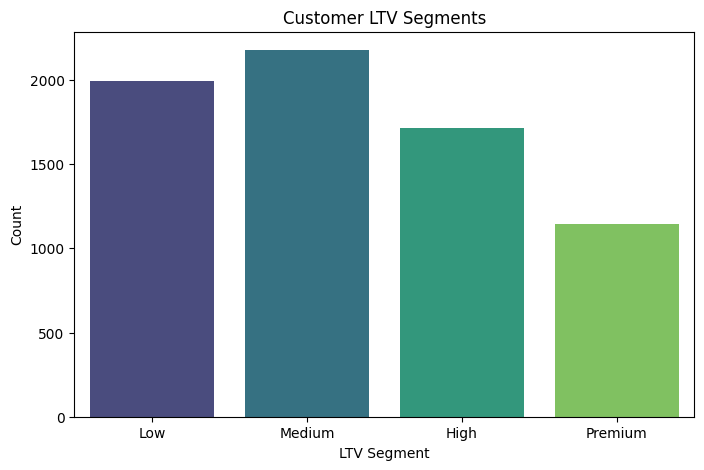

Churn Rate by LTV Segment:
LTV_Segment
Low        41.382766
Medium     23.461892
High       21.924198
Premium    13.648294
Name: Churn, dtype: float64


In [4]:
# Customer LTV Segmentation
df["LTV_Segment"] = pd.cut(df["LTV"], 
                            bins=[0, 500, 2000, 5000, 9000],
                            labels=["Low", "Medium", "High", "Premium"])

# Plot LTV segments
plt.figure(figsize=(8,5))
sns.countplot(x="LTV_Segment", data=df, palette="viridis")
plt.title("Customer LTV Segments")
plt.xlabel("LTV Segment")
plt.ylabel("Count")
plt.show()

# Churn rate by LTV segment
print("Churn Rate by LTV Segment:")
ltv_churn = df.groupby("LTV_Segment")["Churn"].mean() * 100
print(ltv_churn)

In [ ]:
# Save best LTV model (Random Forest)
rf_ltv = RandomForestRegressor(n_estimators=100, random_state=42)
rf_ltv.fit(X_train_ltv, y_train_ltv)

with open("../models/ltv_model.pkl", "wb") as f:
    pickle.dump(rf_ltv, f)

# Save LTV feature names
ltv_features = list(X_ltv.columns)
with open("../models/ltv_features.pkl", "wb") as f:
    pickle.dump(ltv_features, f)

print("LTV model saved!")
print("LTV features saved!")
print("Features:", ltv_features)